In [46]:
%load_ext autoreload 
%autoreload 2 

from src.analysis import * 
from src.visualizations import * 
from src.sentiment import * 
from src.count import *

import pandas as pd 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
df = pd.read_csv("data/clean/lyrics.csv")

# NLP + Benjamin Gibbard 

a little personal project 

**Task**: predict if a song was written for Death Cab for Cutie, The Postal Service, or Benjamin Gibbard's solo work. 
**Features**: TF-IDF representation
**Model**: Logistic Regression
**Evaluation**: Train/test split 

## Basic Word Count

Tokenized on whitespace. Stopwords from the NLTK. 

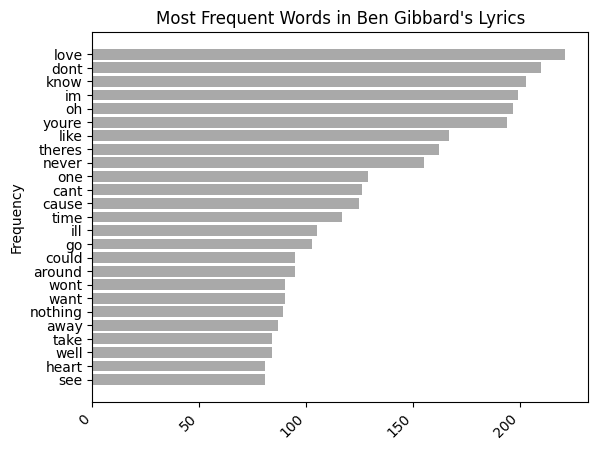

<Figure size 500x300 with 0 Axes>

In [48]:
count_words(df, album= None, n=  25, col = "darkgrey")

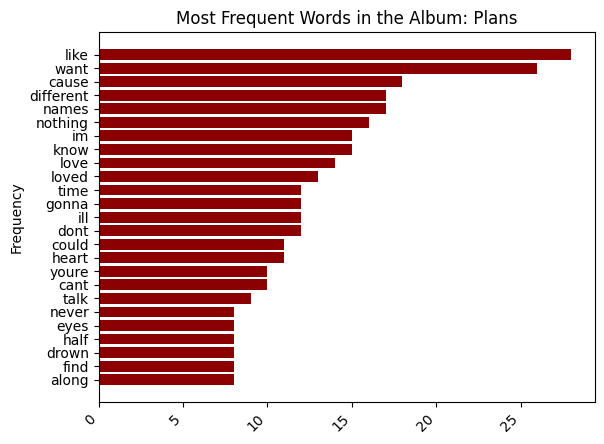

<Figure size 500x300 with 0 Axes>

In [49]:
count_words(df, "Plans", 25, col = "darkred")

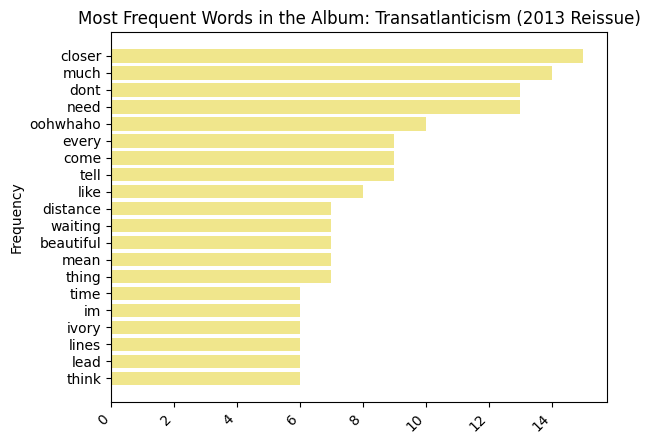

<Figure size 500x300 with 0 Axes>

In [50]:
count_words(df, "Transatlanticism (2013 Reissue)", 20, col = "khaki")

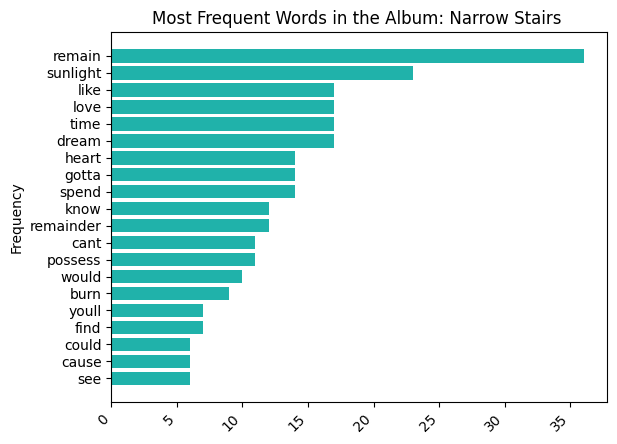

<Figure size 500x300 with 0 Axes>

In [51]:
count_words(df, "Narrow Stairs ", 20, col = "lightseagreen")

## TF-IDF

I used TF-IDF to vectorize each song's lyrics as the data was not too complex. 

In [52]:
tfidf_overall, vec = vectorize(
    df["lyrics_clean"],
    index = df["song_name"]
)

In [53]:
tfidf_overall.shape

(225, 3976)

This returned a matrix of 22 songs, 3859 features (different words)

In [54]:
X_train, X_test, y_train, y_test = split(df)

X_train_tfidf, v = vectorize(X_train)
X_test_tfidf = v.transform(X_test)

I used a logistic regression on the TF-IDF features to predict the artist predicted to be associated with each musical group. 

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [56]:
preds = model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

                     precision    recall  f1-score   support

   Benjamin Gibbard       0.33      0.12      0.18         8
Death Cab for Cutie       0.73      0.91      0.81        33
 The Postal Service       0.00      0.00      0.00         4

           accuracy                           0.69        45
          macro avg       0.36      0.34      0.33        45
       weighted avg       0.60      0.69      0.63        45



/Users/Local/death-cab-lyrics-nlp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


The model had an overall **69%** accuracy at predicting what artist the songs from the test set belong to. It mostly predicts Death Cab for everything. 

Although the model identified correctly **94%** of Death Cab songs, it preformed poorly overall.  

The dataset was unbalanced and struggled to predict songs from Ben Gibbard's solo work or The Postal Service due to the limiated examples for those artists (only one The Postal Service album). 

In [57]:
df = decomp(df, vec)

In [58]:
threshhold = df["x"].std() * 3

df.loc[(df["x"].abs()>threshhold) | 
       (df["y"].abs()>threshhold),
       ["song_name"]]

,song_name
8,I Don’t Know How I Survive
15,Alcoholiday
17,Sidewinder
18,I Don’t Know
23,Unobstructed Views
71,The Ghosts of Beverly Drive
107,Start Again
122,Love Song
136,Before the Bombs
154,All Is Full of Love


I used Principal Component Analysis (PCA) to reduce the large amount of attributes in order to plot the songs in a 2 dimensional space. This axises represent the directions of maximum variance. Observations futher away have a more discinct word patterns. The clusters show songs that share similar vocabularies. 

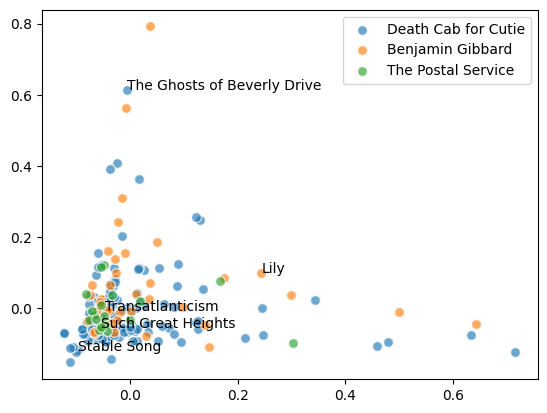

In [59]:
song_components(df)

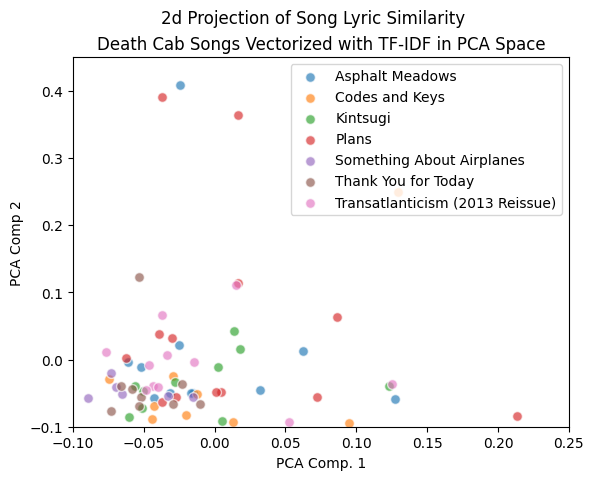

In [60]:
song_components_dc_album(df)

The tight cluster around (-0.05, -0.05) shows that many songs share the same vocabulary patterns across Death Cab for Cutie albums.

## Sentiment Analysis with VADER

In [61]:
import nltk 
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/lilyholmes/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

I used VADER for sentiment analysis because the data set is small and because it would consider elements from the unstripped lyrics, such as punctuation or capitalizations. 

In [62]:
df = vader(df, "lyrics")

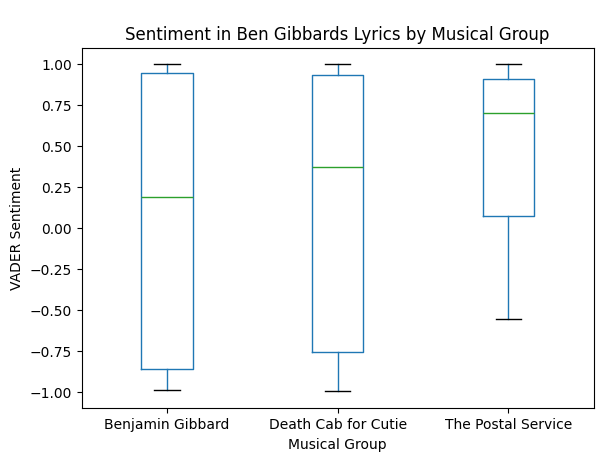

In [63]:
ben_gibbard_boxplot(df)

/Users/Local/death-cab-lyrics-nlp/src/visualizations.py:101: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dc = dc[df["album"].isin(favs)]


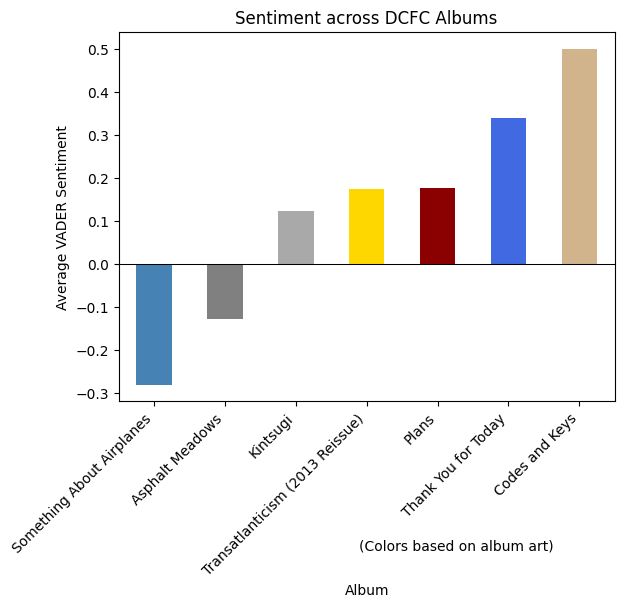

In [64]:
vader_album(df)

In [65]:
df.sort_values("sentiment").head(5)[["song_name", "sentiment"]]

,song_name,sentiment
148,We Laugh Indoors,-0.9980
184,Company Calls,-0.9972
142,Flirted With You All My Life,-0.9960
136,Before the Bombs,-0.9946
78,Good Help (Is So Hard to Find),-0.9941


Songs with the most negative sentiment.

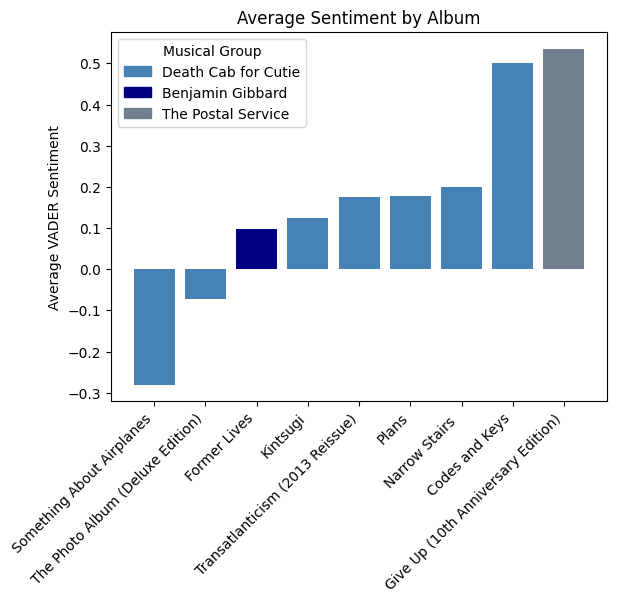

In [66]:
vader_chart(df)

In [ ]:
drop = ["lyrics", "lyrics_clean", "genius_url"]
df_copywrite = df.drop(drop, axis = 1)

df_copywrite.to_csv("data/n_lyrics.csv")

# new csv for public posting only includes album, artist, song name, and x and y components, and sentiment analysis

## Limitations 

A major limitation in analyzing and claiming similarity is that the only input was the natural language. The songs are much more than the lyrics, but this approach ignores the sound and other key aspects. 

More specifically, TF-IDF does not represent the context of each word or the relationship of the words to each other. 

Using VADER (Valence Aware Dictionary sEntiment Reasoner) for semtiment analysis results results in similar issues with context in a phrase. 

Bias might arise in the data frame overall as I manually coded solutions. For example, to solve rows where Ben covered another band, I filtered rows based on those conditions specifically, but could have missed songs. 


## Future Considerations 

As I continue learning, I would like to to come back and improve this project. Potential extensions could be 
* **Interactive visualizations** with Plotly or Altair or something  
* **More advanced models**, especially for sentiment analysis, maybe a transformer based model
* **Clustering** methods with K-means or something to learn more about natural groupings 
* **Temporal analysis** to see how writing changed over time 
* Or improving what is here already 
* Or leaning heavier on AI assisted coding to produce more complex things 

I would value any input or feedback on any aspect of this project, including but not limted to, NLP, visualization, coding conventions, or ML! 

#### Thank you for viewing my project!